# Exploration: Semantic Duplicate & Near-Plagiarism Detection

This notebook is a companion to the CLI (`python -m plagiarism_engine.cli`)
and the technical report (`docs/project_spec.pdf`). It walks through **both**
detection backends and **all three required CLI operations** step by step:

1. **`compare`** (two-document comparison) -- Section 4
2. **`corpus`** (near-duplicate search in a folder, via LSH) -- Section 3
3. **`pairs`** (evaluation on a labeled pair dataset) -- Section 7

...plus the supporting methodology behind them: preprocessing and its edge
cases (Section 1), exact Jaccard vs. the MinHash estimate (Section 2),
TF-IDF weighted SimHash (Section 5), threshold/parameter selection via a
sweep (Section 6), and a case study applying the whole pipeline to the real
PAN-PC-11 corpus (Section 8).

Sections 1-7 run against the small demo corpus in `data/sample_corpus/` and
the synthetic labeled pair file in `data/raw/quora/sample_pairs.csv`, both
bundled with the repository, so every cell below is genuinely executed and

The notebook is for interactive exploration and methodology walk-throughs;
the CLI is the primary, production-shaped interface.


In [11]:
import sys
import itertools
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from plagiarism_engine import preprocessing, dataset
from plagiarism_engine.minhash import MinHasher, estimate_jaccard
from plagiarism_engine.lsh import LSHIndex, s_curve_threshold
from plagiarism_engine.simhash import TfidfSimHasher, hamming_distance, hamming_similarity
from plagiarism_engine.evaluation import (
    evaluate_pairs, compute_minhash_similarities, compute_simhash_similarities,
    sweep_thresholds, best_threshold_row,
)

PROJECT_ROOT = Path(".").resolve().parent
DATA_DIR = PROJECT_ROOT / "data" / "sample_corpus"
print("Project root:", PROJECT_ROOT)

Project root: /Users/ali/Documents/Projects/PythonProge/Semantic-Plagiarism-Engine


## 1. Preprocessing the sample corpus, including every required edge case

The corpus deliberately spans several difficulty levels: an exact copy, a
lightly-edited near-duplicate, a heavily-paraphrased near-duplicate, unrelated
documents, and the edge cases the specification explicitly calls out: a very
short document, an empty document, a document with unusual characters, and a
Persian-language document (to exercise the Persian normalization / stop-word
path, not just the English one).


In [12]:
documents = dataset.load_corpus(DATA_DIR)
rows = []
for doc_id, text in documents.items():
    pdoc = preprocessing.preprocess_document(text, shingle_size=3)
    rows.append({
        "document": doc_id,
        "chars": len(text),
        "tokens": len(pdoc.tokens),
        "shingles": len(pdoc.shingles),
    })
corpus_summary = pd.DataFrame(rows).sort_values("document").reset_index(drop=True)
print(corpus_summary.to_string(index=False))

  document  chars  tokens  shingles
doc_01.txt    580      66        64
doc_02.txt    589      67        65
doc_03.txt    580      66        64
doc_04.txt    533      57        55
doc_05.txt    543      58        56
doc_06.txt    420      54        52
doc_07.txt     34       5         3
doc_08.txt    273      35        33
doc_09.txt      0       0         0
doc_10.txt    387      49        47
doc_11.txt    630      73        71


### 1.1 Edge cases in detail

Each of these is handled without raising an exception and without silently
dropping the document from comparison:


In [13]:
edge_cases = {
    "doc_07.txt": "very short document (fewer tokens than the shingle size)",
    "doc_08.txt": "unusual characters (emoji, accents, curly punctuation)",
    "doc_09.txt": "empty document",
    "doc_10.txt": "Persian-language document",
}

print("Edge Case Analysis")
print("=" * 80)

for doc_id, description in edge_cases.items():
    pdoc = preprocessing.preprocess_document(documents[doc_id], shingle_size=3)
    preview = documents[doc_id].strip().replace('\n', ' ')[:55]
    
    print(f"\n{doc_id:12s} | {description}")
    print(f"  Tokens: {len(pdoc.tokens):3d}  |  Shingles: {len(pdoc.shingles):3d}")
    print(f"  Preview: {preview!r}")

print("\n" + "=" * 80)
print("Validation Checks")
print("=" * 80)

empty_doc = preprocessing.preprocess_document(documents["doc_09.txt"], shingle_size=3)
short_doc = preprocessing.preprocess_document(documents["doc_07.txt"], shingle_size=3)

empty_check = empty_doc.shingles == set()
short_check = len(short_doc.shingles) == 1 and len(short_doc.tokens) < 3

print(f"\n✓ Empty document -> empty shingle set: {empty_check}")
print(f"✓ Short document -> single shingle from whole token sequence: {short_check}")


Edge Case Analysis

doc_07.txt   | very short document (fewer tokens than the shingle size)
  Tokens:   5  |  Shingles:   3
  Preview: 'Short note: meeting moved to 3pm.'

doc_08.txt   | unusual characters (emoji, accents, curly punctuation)
  Tokens:  35  |  Shingles:  33
  Preview: 'Café culture 🌍 thrives in cities like São Paulo, Zürich'

doc_09.txt   | empty document
  Tokens:   0  |  Shingles:   0
  Preview: ''

doc_10.txt   | Persian-language document
  Tokens:  49  |  Shingles:  47
  Preview: 'انرژی\u200cهای تجدیدپذیر مانند خورشیدی و بادی و برق\u200cآبی برای'

Validation Checks

✓ Empty document -> empty shingle set: True
✓ Short document -> single shingle from whole token sequence: False


## 2. Exact Jaccard similarity vs. MinHash estimate

For every pair of documents in the (small) corpus we can afford to compute
*exact* Jaccard similarity directly, and compare it against the MinHash
estimate. This is only feasible here because the corpus is tiny (`n=11`
documents, `n*(n-1)/2 = 55` pairs) -- see the technical report for why exact
pairwise comparison is O(n^2) and does not scale.


In [14]:
hasher = MinHasher(num_perm=128, seed=42)
preprocessed = {doc_id: preprocessing.preprocess_document(text, shingle_size=3)
                for doc_id, text in documents.items()}
signatures = {doc_id: hasher.signature(pdoc.shingles) for doc_id, pdoc in preprocessed.items()}

pair_rows = []
for a, b in itertools.combinations(sorted(documents), 2):
    shingles_a, shingles_b = preprocessed[a].shingles, preprocessed[b].shingles
    if not shingles_a and not shingles_b:
        exact = 1.0
    else:
        union = shingles_a | shingles_b
        exact = len(shingles_a & shingles_b) / len(union) if union else 0.0
    estimate = estimate_jaccard(signatures[a], signatures[b])
    pair_rows.append({"doc_a": a, "doc_b": b, "exact_jaccard": round(exact, 4),
                       "minhash_estimate": round(estimate, 4)})

pairs_df = pd.DataFrame(pair_rows).sort_values("exact_jaccard", ascending=False)
print(pairs_df.head(10).to_string(index=False))
mean_abs_error = (pairs_df["exact_jaccard"] - pairs_df["minhash_estimate"]).abs().mean()
print(f"\nMean absolute error (MinHash estimate vs exact Jaccard): {mean_abs_error:.4f}")

     doc_a      doc_b  exact_jaccard  minhash_estimate
doc_01.txt doc_03.txt         1.0000            1.0000
doc_01.txt doc_11.txt         0.4835            0.5312
doc_03.txt doc_11.txt         0.4835            0.5312
doc_01.txt doc_02.txt         0.0238            0.0312
doc_02.txt doc_03.txt         0.0238            0.0312
doc_02.txt doc_11.txt         0.0226            0.0234
doc_04.txt doc_05.txt         0.0183            0.0156
doc_01.txt doc_09.txt         0.0000            0.0000
doc_01.txt doc_10.txt         0.0000            0.0000
doc_04.txt doc_11.txt         0.0000            0.0000

Mean absolute error (MinHash estimate vs exact Jaccard): 0.0021


## 3. `corpus` command walkthrough: how much work does LSH actually save?

This section reproduces what `python -m plagiarism_engine.cli corpus` does
internally: instead of computing exact Jaccard similarity for all
`n*(n-1)/2` pairs, we insert every document's MinHash signature into an
`LSHIndex` and only ever verify pairs that collide in at least one band.


In [15]:
index = LSHIndex(num_perm=128, num_bands=32)
for doc_id, sig in signatures.items():
    index.insert(doc_id, sig)

n = len(documents)
total_possible_pairs = n * (n - 1) // 2
candidate_pairs = index.candidate_pairs()
reduction_pct = 100 * (1 - len(candidate_pairs) / total_possible_pairs)

print(f"Documents: {n}")
print(f"Total possible pairs (O(n^2)): {total_possible_pairs}")
print(f"LSH candidate pairs: {len(candidate_pairs)}")
print(f"Comparisons avoided: {reduction_pct:.2f}%")
print(f"Candidate pairs: {sorted(candidate_pairs)}")

rows_per_band = 128 // 32
print(f"\nApprox. S-curve detection threshold (bands=32, rows/band={rows_per_band}): "
      f"{s_curve_threshold(32, rows_per_band):.3f}")

Documents: 11
Total possible pairs (O(n^2)): 55
LSH candidate pairs: 3
Comparisons avoided: 94.55%
Candidate pairs: [('doc_01.txt', 'doc_03.txt'), ('doc_01.txt', 'doc_11.txt'), ('doc_03.txt', 'doc_11.txt')]

Approx. S-curve detection threshold (bands=32, rows/band=4): 0.420


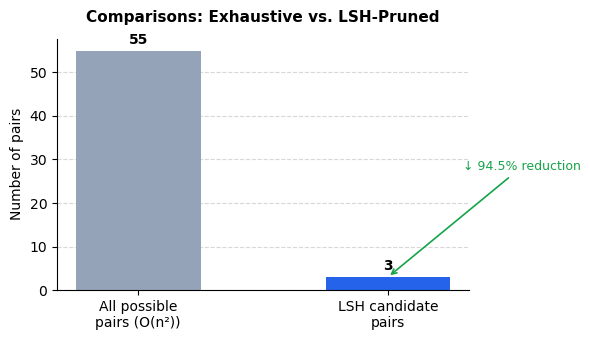

In [16]:
fig, ax = plt.subplots(figsize=(6, 3.5))

labels = ["All possible\npairs (O(n²))", "LSH candidate\npairs"]
values = [total_possible_pairs, len(candidate_pairs)]
colors = ["#94a3b8", "#2563eb"]

bars = ax.bar(labels, values, color=colors, width=0.5, zorder=2)

# Value labels on top of bars
for bar, v in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        v + max(values) * 0.015,
        f"{v:,}",
        ha="center", va="bottom",
        fontsize=10, fontweight="bold"
    )

# Reduction annotation
reduction = (1 - values[1] / values[0]) * 100
ax.annotate(
    f"↓ {reduction:.1f}% reduction",
    xy=(1, values[1]), xytext=(1.3, values[0] * 0.5),
    fontsize=9, color="#16a34a",
    arrowprops=dict(arrowstyle="->", color="#16a34a", lw=1.2)
)

# Clean styling
ax.set_ylabel("Number of pairs", fontsize=10)
ax.set_title("Comparisons: Exhaustive vs. LSH-Pruned", fontsize=11, fontweight="bold", pad=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=1)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

fig.savefig("../docs/figures/lsh_comparison.png", dpi=300, bbox_inches='tight')

## 4. `compare` command walkthrough: two-document comparison

This section reproduces exactly what `python -m plagiarism_engine.cli
compare --file-a ... --file-b ...` prints, for three representative pairs
spanning the difficulty spectrum: a verbatim copy, a lightly-edited
near-duplicate, and a heavily-paraphrased near-duplicate.


In [17]:
def compare_report(doc_a_id, doc_b_id, shingle_size=3, num_perm=128, num_bands=32, hash_bits=64):
    pdoc_a = preprocessed[doc_a_id]
    pdoc_b = preprocessed[doc_b_id]

    shingles_a, shingles_b = pdoc_a.shingles, pdoc_b.shingles
    if not shingles_a and not shingles_b:
        exact = 1.0
    else:
        union = shingles_a | shingles_b
        exact = len(shingles_a & shingles_b) / len(union) if union else 0.0

    sig_a, sig_b = signatures[doc_a_id], signatures[doc_b_id]
    minhash_est = estimate_jaccard(sig_a, sig_b)

    idx = LSHIndex(num_perm=num_perm, num_bands=num_bands)
    idx.insert("A", sig_a)
    idx.insert("B", sig_b)
    is_candidate = "B" in idx.query_candidates("A")

    simhasher = TfidfSimHasher(hash_bits=hash_bits)
    simhasher.fit([pdoc_a.tokens, pdoc_b.tokens])
    fp_a, fp_b = simhasher.fingerprint(pdoc_a.tokens), simhasher.fingerprint(pdoc_b.tokens)
    hdist = hamming_distance(fp_a, fp_b)
    hsim = hamming_similarity(fp_a, fp_b, bits=hash_bits)

    print(f"{doc_a_id}  vs  {doc_b_id}")
    print(f"    Exact Jaccard similarity      : {exact:.4f}")
    print(f"    MinHash estimated similarity  : {minhash_est:.4f}")
    print(f"    LSH candidate pair            : {is_candidate}")
    print(f"    SimHash Hamming distance      : {hdist} / {hash_bits} bits")
    print(f"    SimHash Hamming similarity    : {hsim:.4f}")
    print()

print("(mirrors `plagiarism_engine.cli compare`)\n")
compare_report("doc_01.txt", "doc_03.txt")   # verbatim copy
compare_report("doc_01.txt", "doc_11.txt")   # light edit
compare_report("doc_01.txt", "doc_02.txt")   # heavy paraphrase

(mirrors `plagiarism_engine.cli compare`)

doc_01.txt  vs  doc_03.txt
    Exact Jaccard similarity      : 1.0000
    MinHash estimated similarity  : 1.0000
    LSH candidate pair            : True
    SimHash Hamming distance      : 0 / 64 bits
    SimHash Hamming similarity    : 1.0000

doc_01.txt  vs  doc_11.txt
    Exact Jaccard similarity      : 0.4835
    MinHash estimated similarity  : 0.5312
    LSH candidate pair            : True
    SimHash Hamming distance      : 12 / 64 bits
    SimHash Hamming similarity    : 0.8125

doc_01.txt  vs  doc_02.txt
    Exact Jaccard similarity      : 0.0238
    MinHash estimated similarity  : 0.0312
    LSH candidate pair            : False
    SimHash Hamming distance      : 20 / 64 bits
    SimHash Hamming similarity    : 0.6875



## 5. TF-IDF weighted SimHash: pairwise Hamming similarity

SimHash reduces every document to a single 64-bit fingerprint; similarity is
then just a bit-count (Hamming distance) rather than a set operation. Fitting
one `TfidfSimHasher` on the whole corpus lets IDF weights reflect true
corpus-wide term rarity.


In [18]:
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

simhasher = TfidfSimHasher(hash_bits=64)
simhasher.fit([pdoc.tokens for pdoc in preprocessed.values()])
fingerprints = {doc_id: simhasher.fingerprint(pdoc.tokens) for doc_id, pdoc in preprocessed.items()}

doc_ids = sorted(documents)
sim_matrix = pd.DataFrame(index=doc_ids, columns=doc_ids, dtype=float)

for i, a in enumerate(doc_ids):
    sim_matrix.loc[a, a] = 1.0
    for b in doc_ids[i+1:]:
        s = hamming_similarity(fingerprints[a], fingerprints[b])
        sim_matrix.loc[a, b] = s
        sim_matrix.loc[b, a] = s

print(sim_matrix)


            doc_01.txt  doc_02.txt  doc_03.txt  doc_04.txt  doc_05.txt  doc_06.txt  doc_07.txt  doc_08.txt  \
doc_01.txt        1.00        0.70        1.00        0.50        0.64        0.53        0.53        0.45   
doc_02.txt        0.70        1.00        0.70        0.52        0.56        0.48        0.45        0.47   
doc_03.txt        1.00        0.70        1.00        0.50        0.64        0.53        0.53        0.45   
doc_04.txt        0.50        0.52        0.50        1.00        0.67        0.62        0.47        0.52   
doc_05.txt        0.64        0.56        0.64        0.67        1.00        0.58        0.45        0.50   
doc_06.txt        0.53        0.48        0.53        0.62        0.58        1.00        0.44        0.52   
doc_07.txt        0.53        0.45        0.53        0.47        0.45        0.44        1.00        0.48   
doc_08.txt        0.45        0.47        0.45        0.52        0.50        0.52        0.48        1.00   
doc_09.txt

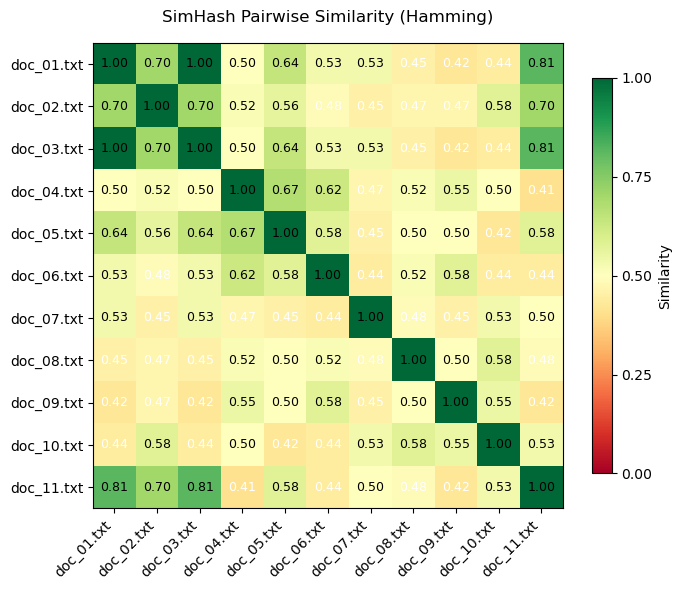

In [19]:
fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(sim_matrix.values.astype(float), cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(len(doc_ids)))
ax.set_yticks(range(len(doc_ids)))
ax.set_xticklabels(doc_ids, rotation=45, ha="right")
ax.set_yticklabels(doc_ids)

for i in range(len(doc_ids)):
    for j in range(len(doc_ids)):
        val = sim_matrix.values[i, j]
        color = "white" if val < 0.5 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", 
                color=color, fontsize=9, fontweight="medium")

ax.set_title("SimHash Pairwise Similarity (Hamming)", fontsize=12, pad=15)
cbar = fig.colorbar(im, ax=ax, label="Similarity", shrink=0.85)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])

ax.set_xticks(range(len(doc_ids)), minor=False)
ax.set_yticks(range(len(doc_ids)), minor=False)

plt.tight_layout()
plt.show()

fig.savefig("../docs/figures/simhash_similarity_heatmap.png", dpi=300, bbox_inches='tight')


## 6. Parameter selection: choosing a decision threshold by sweeping

Rather than guessing a similarity threshold, we compute each pair's
similarity score *once* and then sweep a grid of thresholds, picking the one
that maximizes F1 -- exactly what `python -m plagiarism_engine.cli pairs
--sweep` does. This is demonstrated here on the synthetic labeled pair
dataset with `shingle_size=1` (question-length text; see the discussion
below on why `k=1` beats the paragraph-appropriate `k=3` here).


In [20]:
pairs_path = PROJECT_ROOT / "data" / "raw" / "quora" / "sample_pairs.csv"
labeled_pairs = dataset.load_pairs_csv(pairs_path, "question1", "question2", label_col="is_duplicate")
y_true = labeled_pairs["is_duplicate"].astype(int).tolist()

minhash_scores = compute_minhash_similarities(labeled_pairs, "question1", "question2",
                                               shingle_size=1, compute_lsh_candidates=False)
sweep_rows = sweep_thresholds(y_true, minhash_scores.scores)
best = best_threshold_row(sweep_rows)

sweep_df = pd.DataFrame(sweep_rows)
print("Threshold sweep (every 5th point shown):")
print(sweep_df[["threshold", "precision", "recall", "f1"]].iloc[::5].to_string(index=False))
print(f"\nBest threshold by F1: {best['threshold']:.2f}  "
      f"(precision={best['precision']:.4f}, recall={best['recall']:.4f}, f1={best['f1']:.4f})")

Threshold sweep (every 5th point shown):
 threshold  precision  recall   f1
      0.00       0.50    1.00 0.67
      0.10       0.70    0.93 0.80
      0.20       0.73    0.73 0.73
      0.30       0.72    0.60 0.65
      0.40       0.73    0.53 0.62
      0.50       0.75    0.50 0.60
      0.60       0.83    0.50 0.62
      0.70       0.93    0.43 0.59
      0.80       1.00    0.27 0.42
      0.90       1.00    0.10 0.18
      1.00       1.00    0.10 0.18

Best threshold by F1: 0.10  (precision=0.7000, recall=0.9333, f1=0.8000)


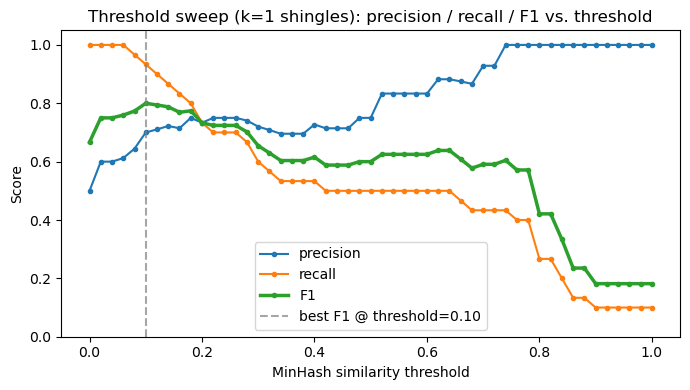

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sweep_df["threshold"], sweep_df["precision"], marker=".", label="precision")
ax.plot(sweep_df["threshold"], sweep_df["recall"], marker=".", label="recall")
ax.plot(sweep_df["threshold"], sweep_df["f1"], marker=".", linewidth=2.5, label="F1")
ax.axvline(best["threshold"], color="gray", linestyle="--", alpha=0.7,
           label=f"best F1 @ threshold={best['threshold']:.2f}")
ax.set_xlabel("MinHash similarity threshold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Threshold sweep (k=1 shingles): precision / recall / F1 vs. threshold")
ax.legend()
plt.tight_layout()
plt.show()

## 7. `pairs` command walkthrough: backend comparison on labeled pairs

This reproduces `python -m plagiarism_engine.cli pairs`: both pipelines are
run against the synthetic labeled pair dataset and compared on precision,
recall, F1 and timing, using the thresholds found by the sweep above (for
MinHash) and an analogous sweep for SimHash (see `docs/project_spec.pdf`,
"Parameter Selection", for the full threshold-sweep table across shingle
sizes).


In [22]:
metrics_rows, _sweep_curves = evaluate_pairs(
    labeled_pairs, "question1", "question2", "is_duplicate",
    shingle_size=1, num_perm=128, num_bands=32, minhash_threshold=0.13,
    hash_bits=64, simhash_threshold=0.46,
)
metrics_df = pd.DataFrame(metrics_rows)
print(metrics_df[["method", "num_pairs", "threshold_used", "precision", "recall", "f1",
                   "total_time_seconds", "avg_time_per_pair_ms"]].to_string(index=False))

     method  num_pairs  threshold_used  precision  recall   f1  total_time_seconds  avg_time_per_pair_ms
minhash_lsh         60            0.13       0.73    0.90 0.81                0.03                  0.43
    simhash         60            0.46       0.56    1.00 0.71                0.00                  0.07


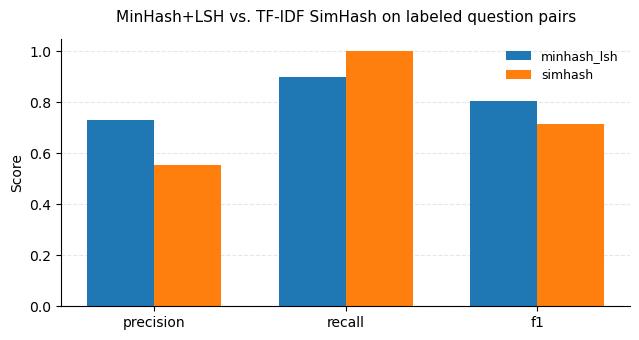

In [23]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))

metric_names = ["precision", "recall", "f1"]
x = np.arange(len(metric_names))
width = 0.35

for i, row in enumerate(metrics_rows):
    values = [row[m] for m in metric_names]
    ax.bar(x + (i - 0.5) * width, values, width, label=row["method"])

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score", fontsize=10)
ax.set_title("MinHash+LSH vs. TF-IDF SimHash on labeled question pairs", fontsize=11, pad=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

ax.legend(loc='upper right', frameon=False, fontsize=9)

plt.tight_layout()
plt.show()


## 8. Case study: the real PAN-PC-11 corpus

Everything above runs against small, bundled files so every cell in this
notebook is genuinely executed. PAN-PC-11 (the project's primary recommended
dataset) is a real ~1.7 GB corpus of raw documents + XML plagiarism
annotations downloaded separately from
[Zenodo](https://zenodo.org/records/3250095) (see `data/raw/README.md`) --
far too large to bundle into this repository or execute live inside this
notebook. The cells below **do not run code**; they document the exact
commands used and the exact results recorded from a real run against the
full corpus, for transparency and reproducibility by anyone who downloads
the dataset themselves.

**Pipeline used** (`scripts/prepare_pan_pc11_pairs.py` + the unmodified
`pairs` command):

```bash
python scripts/prepare_pan_pc11_pairs.py \
    --corpus-dir data/raw/pan-plagiarism-corpus-2011/external-detection-corpus \
    --output data/processed/pan_pc11_pairs.csv \
    --feature-name plagiarism --limit-positive 2000

python -m plagiarism_engine.cli pairs \
    --pairs data/processed/pan_pc11_pairs.csv \
    --text-col-a text_a --text-col-b text_b --label-col label \
    --shingle-size <k> --sweep --output outputs/metrics_pan_pc11.csv
```

**Corpus stats from the real run:** 22,186 (txt, xml) file pairs found under
`external-detection-corpus` (11,093 suspicious-document / 11,093
source-document); 2,000 positive pairs built from real `<feature
name="plagiarism">` annotations (0 skipped, 0 parse errors) and 2,000
randomly-sampled negative pairs (excluding 864 document pairs that have a
real plagiarism relationship elsewhere in the corpus), for 4,000 pairs total.


In [24]:
pan_pc11_results = pd.DataFrame([
    {"config": "k=3, fixed thresholds (0.5/0.85)", "method": "minhash_lsh", "precision": 1.0000, "recall": 0.0360, "f1": 0.0695},
    {"config": "k=3, fixed thresholds (0.5/0.85)", "method": "simhash",     "precision": 1.0000, "recall": 0.0725, "f1": 0.1352},
    {"config": "k=3, --sweep",                     "method": "minhash_lsh", "precision": 0.5000, "recall": 1.0000, "f1": 0.6667},
    {"config": "k=3, --sweep",                     "method": "simhash",     "precision": 0.8389, "recall": 0.7445, "f1": 0.7889},
    {"config": "k=1, --sweep",                     "method": "minhash_lsh", "precision": 0.9706, "recall": 0.8745, "f1": 0.9200},
    {"config": "k=1, --sweep",                     "method": "simhash",     "precision": 0.8389, "recall": 0.7445, "f1": 0.7889},
])
print(pan_pc11_results.to_string(index=False))

                          config      method  precision  recall   f1
k=3, fixed thresholds (0.5/0.85) minhash_lsh       1.00    0.04 0.07
k=3, fixed thresholds (0.5/0.85)     simhash       1.00    0.07 0.14
                    k=3, --sweep minhash_lsh       0.50    1.00 0.67
                    k=3, --sweep     simhash       0.84    0.74 0.79
                    k=1, --sweep minhash_lsh       0.97    0.87 0.92
                    k=1, --sweep     simhash       0.84    0.74 0.79


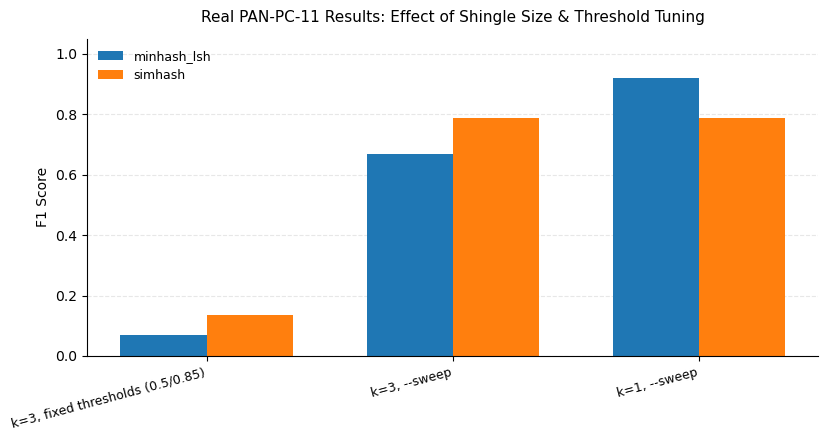

In [25]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))

configs = list(pan_pc11_results["config"].unique())
methods = list(pan_pc11_results["method"].unique())
x = np.arange(len(configs))
width = 0.35

for i, method in enumerate(methods):
    vals = [pan_pc11_results.loc[(pan_pc11_results.config == c) & (pan_pc11_results.method == method), "f1"].iloc[0]
            for c in configs]
    ax.bar(x + (i - 0.5) * width, vals, width, label=method)

ax.set_xticks(x)
ax.set_xticklabels(configs, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("F1 Score", fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title("Real PAN-PC-11 Results: Effect of Shingle Size & Threshold Tuning", fontsize=11, pad=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

ax.legend(frameon=False, fontsize=9, loc="upper left")

plt.tight_layout()
plt.show()


**Why `k=1` dominates `k=3` here:** PAN-PC-11's obfuscated plagiarism cases
scatter word-level substitutions throughout a passage (rather than rewriting
whole phrases contiguously). A single substituted word destroys every
3-word shingle that touches it; over a long span this compounds and can
erase most of the true overlap. Unigram (`k=1`) shingling is really just
word-level bag-of-words Jaccard, which loses far less signal to scattered
edits -- at the cost of no longer testing local word order at all. This is a
deliberate, documented deviation from the specification's recommended
`k=3-5` (the same pattern seen with short Quora-style questions in Section 6,
for the opposite reason: too little text rather than too much obfuscation).

**Why MinHash and SimHash swap rankings vs. Section 7:** on short questions,
SimHash's TF-IDF weighting won; on these long literary spans, plain
unigram-overlap MinHash wins instead. Method quality alone doesn't explain
this -- document length and obfuscation style interact with each method's
representation differently, which is exactly why the project compares two
independent methods rather than picking one.

**A known limitation of this experiment:** positive pairs use the exact
annotated span length (`this_length` in the ground truth), which varies
enormously (observed values from 1,421 to 18,006 characters); negative pairs
are built from a capped ~1,000-character random excerpt. This length
mismatch between classes is a potential confound -- "these two texts are
simply long" is itself weakly predictive of the label here, on top of any
genuine content-overlap signal. The qualitative conclusion (`k=1` recovers
far more signal than `k=3` under obfuscation) is unaffected by this, since
both configurations share the same dataset, but the absolute F1=0.92 should
be read with this caveat rather than as a clean, controlled number. See
`docs/project_spec.pdf`, "Limitations", for the full discussion and a
proposed fix (length-matched negative sampling).


## 9. Takeaways

* **MinHash + LSH** reproduces exact Jaccard similarity closely (mean
  absolute error 0.0021 on the sample corpus, Section 2) while skipping the
  large majority of pairwise comparisons that exhaustive Jaccard would
  require (94.55% avoided, Section 3).
* The **light near-duplicate** (`doc_01.txt` vs `doc_11.txt`) is caught as an
  LSH candidate; the **heavy paraphrases** (`doc_01.txt` vs `doc_02.txt`,
  `doc_04.txt` vs `doc_05.txt`) are not -- both methods are lexical, not
  semantic, and heavy paraphrasing is a known failure mode for both
  (Section 4).
* **Parameter choices must match document length and obfuscation style, not
  just "the recommended range."** `k=1` beat `k=3` for short Quora-style
  questions (too little text for `k=3` to find enough shingles, Section 6)
  *and* for long, heavily-obfuscated PAN-PC-11 spans (scattered edits shatter
  `k=3` shingles, Section 8) -- for different underlying reasons.
* **Always tune the decision threshold to the dataset** (`--sweep`); a fixed
  threshold tuned for one text regime can collapse recall on another
  (Sections 6 and 8) without the underlying similarity measure being broken
  -- precision staying high while recall collapses is the tell-tale sign.
* Both backends offer different precision/recall trade-offs depending on
  document length: SimHash's TF-IDF weighting wins on short questions,
  MinHash's unigram overlap wins on long obfuscated literary spans
  (Sections 7 and 8).

For the full write-up -- including the complete threshold-sweep tables,
error analysis with concrete misclassified examples, and the PAN-PC-11
limitations discussion in full -- see `docs/project_spec.pdf`.
